In [116]:
import numpy as np
import pandas as pd

In [117]:
spam = pd.read_csv('spam.csv',encoding = "cp1252") # there was some problem with utf-8 encoding while reading the file


In [118]:
spam.shape

(5572, 5)

In [119]:
spam.head(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN


# Data Cleaning

- for spam detection we really don't required other column other then the text and target, if data is less as doesn't provide any infor
- change the name of column
- ham - 0, spam -1
- remove na and duplicate

In [120]:
spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


then unamed column only have 50, 12, 6 data so we can remove them

In [121]:

spam.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [122]:
spam.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [123]:
# ham - 0 and spam 1 or any value
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
spam['target'] = encoder.fit_transform(spam['target'])

In [124]:
spam.isna().sum()

target    0
text      0
dtype: int64

In [125]:
spam.duplicated().sum()

np.int64(403)

In [126]:
spam = spam.drop_duplicates(keep='first')

In [127]:
spam

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [128]:
spam.shape

(5169, 2)

# EDA

- count of each class
- how the count of class changes with word, character, sentence
- common words in data
- data distribution
- correlation between column

In [129]:
spam['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

The 0 class has more examples then 1 class. Looks like a imbalanced class, have to take care of it while building model

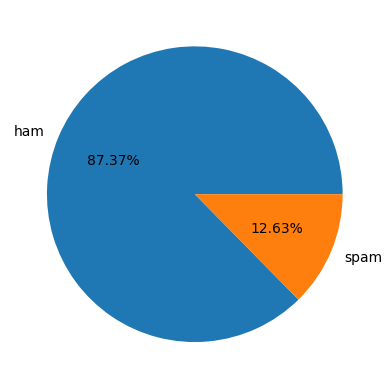

In [130]:
import matplotlib.pyplot as plt

plt.pie(spam['target'].value_counts(),labels=['ham', 'spam'],autopct="%0.2f%%")
plt.show()

In [131]:
# the number of characeter
spam['num_character'] = spam['text'].apply(len)

In [132]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/akash/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [133]:
# count the number words
# first we tokenize the text and then count the number of words
spam['nums_words'] = spam['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [134]:
# tokenize each sentence
spam['nums_sentence'] = spam['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [135]:
# relation between token and number of spam and no spam
spam[['num_character', 'nums_words', 'nums_sentence']].describe()

,num_character,nums_words,nums_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


- on average there are 78 words in sentence +- 58 words
- number of words are 18 on average and minmum is 1 and max is 220 way larger then average
- we can plot a box plot form this data also

In [136]:
# stats of spam
spam[spam['target'] == 1][['num_character', 'nums_words', 'nums_sentence']].describe()

,num_character,nums_words,nums_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [137]:
# stat of ham
spam[spam['target'] == 0][['num_character', 'nums_words', 'nums_sentence']].describe()

,num_character,nums_words,nums_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [138]:
import seaborn as sns

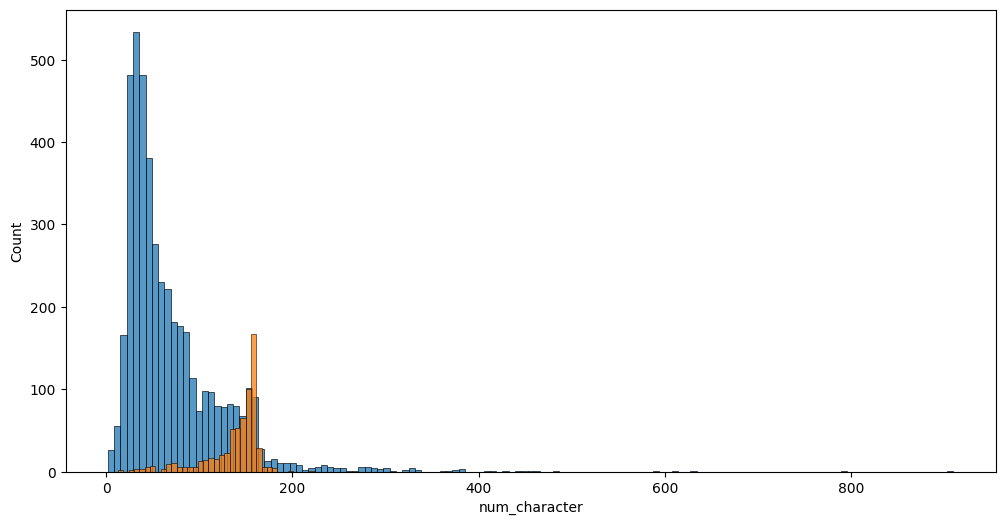

In [139]:
# histogram for num of character
plt.figure(figsize=(12,6))
sns.histplot(spam[spam['target'] == 0]['num_character'])
sns.histplot(spam[spam['target'] == 1]['num_character'])
plt.show()

As the number of character increases in sms the count of 0 increase i.e num of character is 30 or 40 then most the sms are ham
for spam if character is larger then spam

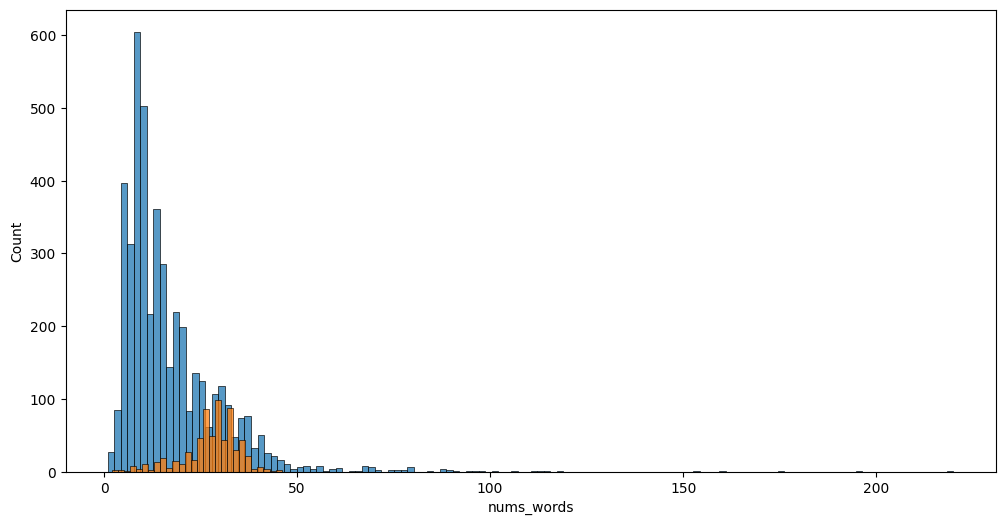

In [140]:
# histogram for num of words
plt.figure(figsize=(12,6))
sns.histplot(spam[spam['target'] == 0]['nums_words'])
sns.histplot(spam[spam['target'] == 1]['nums_words'])
plt.show()

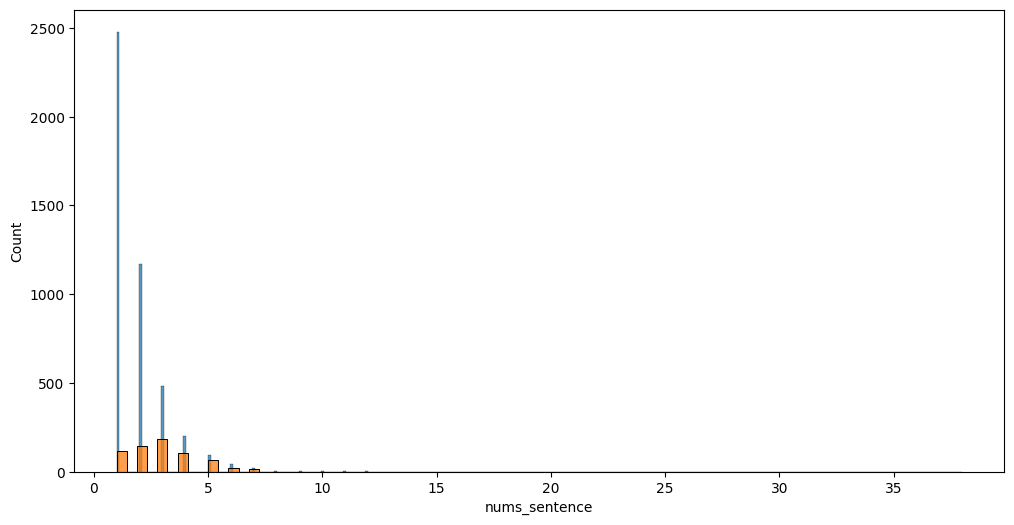

In [141]:
# histogram for num of words
plt.figure(figsize=(12,6))
sns.histplot(spam[spam['target'] == 0]['nums_sentence'])
sns.histplot(spam[spam['target'] == 1]['nums_sentence'])
plt.show()

The sentence historgram is small, as only one two sentence are there in sms
no. of sms with sentence count 1 has most ham messages

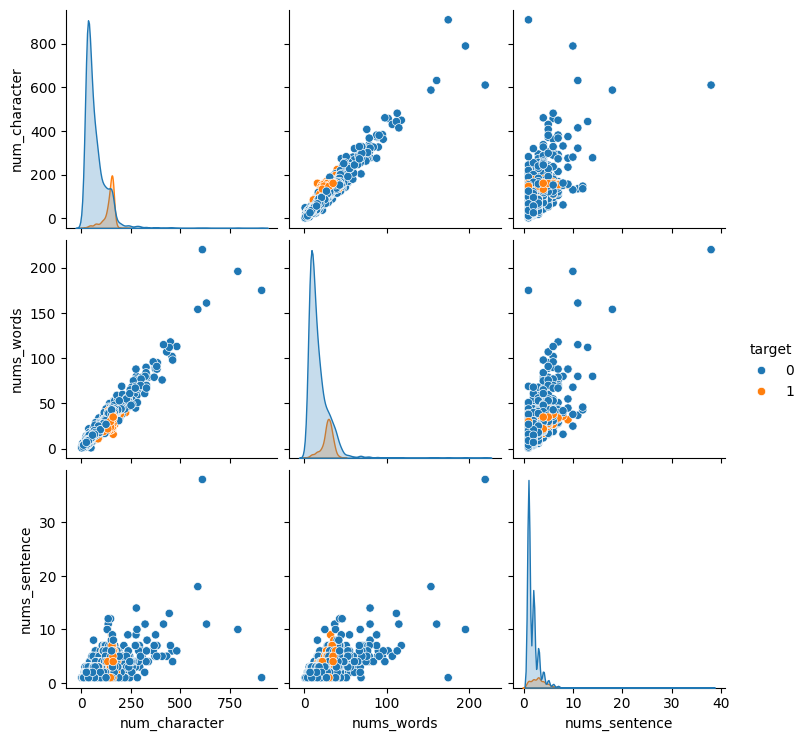

In [142]:
# relation between all the columns i.e number of character, words, sentence
sns.pairplot(spam, hue='target')

<Axes: >

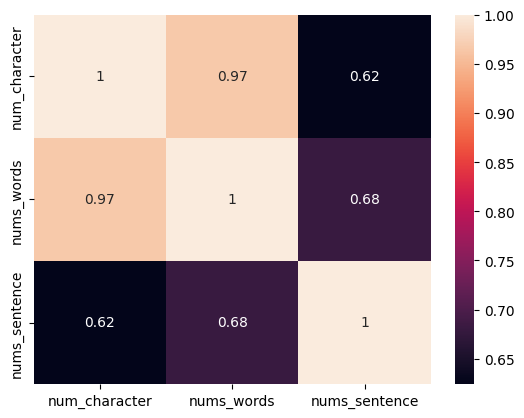

In [143]:
# correlation matrix
sns.heatmap(spam[['num_character', 'nums_words', 'nums_sentence']].corr(), annot=True)

# Data pre-processing
- lower case
- tokenize
- remove special character
- remove punctuation
- remove stopword
- steaming


In [144]:
spam['text'].iloc[0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [145]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

def text_transform(text):

    stop_words = set(stopwords.words('english'))
    trans_text = word_tokenize(text.lower())

    trans_text = [x for x in trans_text if not x in stop_words] # remove stopword
    trans_text = [x for x in trans_text if x.isalnum()]# remove punctations and special character

    # stemming
    stemming = PorterStemmer()
    trans_text = [stemming.stem(x) for x in trans_text]

    return " ".join(trans_text)


In [146]:
spam['transform_text'] = spam['text'].apply(text_transform)

In [147]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

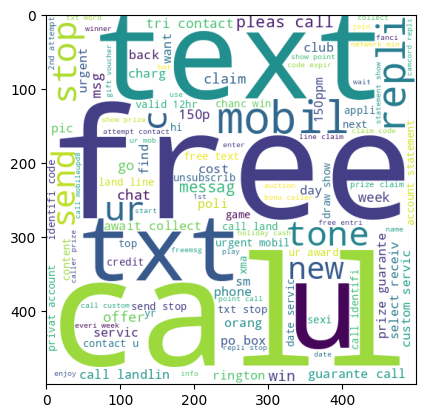

In [152]:
spam_wordcloud = wc.generate(spam[spam['target'] == 1]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wordcloud)

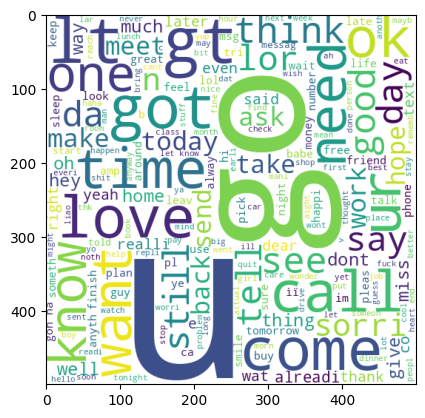

In [151]:
spam_wordcloud = wc.generate(spam[spam['target'] == 0]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wordcloud)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'text'),
  Text(5, 0, 'u'),
  Text(6, 0, 'ur'),
  Text(7, 0, 'mobil'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'repli'),
  Text(10, 0, 'claim'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'get'),
  Text(14, 0, 'new'),
  Text(15, 0, 'servic'),
  Text(16, 0, 'tone'),
  Text(17, 0, 'send'),
  Text(18, 0, 'urgent'),
  Text(19, 0, 'nokia'),
  Text(20, 0, 'contact'),
  Text(21, 0, 'award'),
  Text(22, 0, 'phone'),
  Text(23, 0, 'cash'),
  Text(24, 0, 'pleas'),
  Text(25, 0, 'week'),
  Text(26, 0, 'win'),
  Text(27, 0, 'c'),
  Text(28, 0, 'collect'),
  Text(29, 0, 'min')])

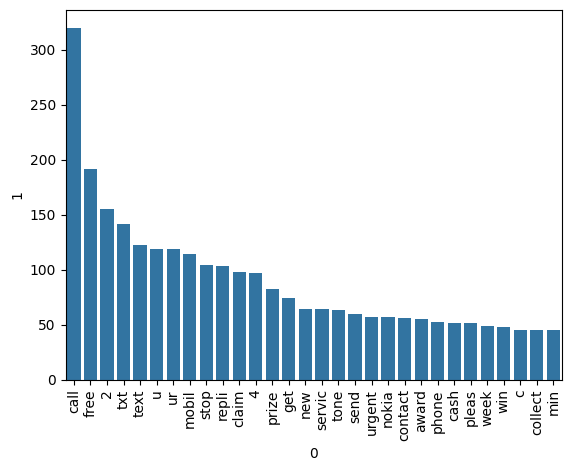

In [166]:
# most common words
from collections import Counter

spam_corpus = []
for msg in spam[spam['target'] == 1]['transform_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'u'),
  Text(1, 0, 'go'),
  Text(2, 0, 'get'),
  Text(3, 0, 'gt'),
  Text(4, 0, 'lt'),
  Text(5, 0, '2'),
  Text(6, 0, 'come'),
  Text(7, 0, 'got'),
  Text(8, 0, 'know'),
  Text(9, 0, 'like'),
  Text(10, 0, 'call'),
  Text(11, 0, 'time'),
  Text(12, 0, 'ok'),
  Text(13, 0, 'love'),
  Text(14, 0, 'good'),
  Text(15, 0, 'want'),
  Text(16, 0, 'ur'),
  Text(17, 0, 'day'),
  Text(18, 0, 'need'),
  Text(19, 0, 'one'),
  Text(20, 0, 'lor'),
  Text(21, 0, '4'),
  Text(22, 0, 'home'),
  Text(23, 0, 'think'),
  Text(24, 0, 'see'),
  Text(25, 0, 'take'),
  Text(26, 0, 'still'),
  Text(27, 0, 'da'),
  Text(28, 0, 'tell'),
  Text(29, 0, 'make')])

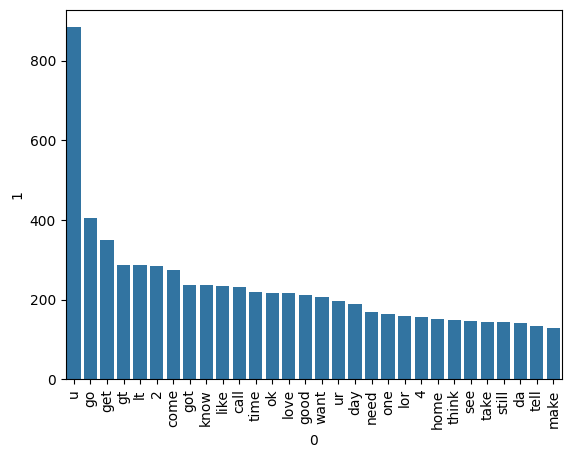

In [167]:
ham_corpus = []
for msg in spam[spam['target'] == 0]['transform_text'].tolist():
    for words in msg.split():
        ham_corpus.append(words)

sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')

# Model Building

- vectorize
- train test split
- select model and train

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# two different vectorizer can give different result
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [203]:
X = cv.fit_transform(spam['text']).toarray()
X = tfidf.fit_transform(spam['text']).toarray()
y = spam['target'].values

In [204]:
print(X.shape, y.shape)

(5169, 8673) (5169,)


In [205]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [206]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [207]:
gnb = GaussianNB()
bnb = BernoulliNB()
mnb = MultinomialNB()

In [208]:
models = {
    'gnb': gnb,
    'bnb': bnb,
    'mnb': mnb
}

In [211]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_predict = model.predict(X_test)
    print(y_predict)
    print(name)
    print(accuracy_score(y_test, y_predict))
    print(confusion_matrix(y_test, y_predict))
    print(precision_score(y_test, y_predict))
    print('-'*60)

[0 0 1 ... 0 0 0]
gnb
0.9110251450676983
[[823  73]
 [ 19 119]]
0.6197916666666666
------------------------------------------------------------
[0 0 0 ... 0 0 0]
bnb
0.9777562862669246
[[893   3]
 [ 20 118]]
0.9752066115702479
------------------------------------------------------------
[0 0 0 ... 0 0 0]
mnb
0.9506769825918762
[[896   0]
 [ 51  87]]
1.0
------------------------------------------------------------


In [210]:
import pickle

pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))